# Analise das metricas de prompt optimization do ncf

Este notebook percorre os diretorios `mmr_lambda_*` dentro de `out/prompt_optimization/Llama3.1-I/ncf`, procura os arquivos `optimization_process_metadata.json` e plota a evolucao das metricas por epoca para os experimentos do algoritmo `ncf`.

Ele tambem incorpora os resultados de teste salvos em `out/test_explainability`, mostrando:
- o teste `without_optimization`, exibido uma unica vez;
- e os testes `with_optimization` correspondentes a cada configuracao do `ncf`.

Observacoes:
- O eixo x representa a epoca.
- O eixo y representa o valor da metrica.
- Quando disponivel, o notebook plota as curvas de treino (`train_metric`) e validacao (`val_metric`).
- Para cada grafico, o notebook tambem exibe uma tabela pandas com os valores por epoca.
- Diretorios sem `optimization_process_metadata.json` sao reportados em tela.


In [1]:
import json
import os
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")

SAVE_FIGURES = False

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "run_prompt_optimizer.py").exists() and (candidate / "out").exists():
            return candidate
    raise FileNotFoundError(
        "Nao foi possivel localizar a raiz de explainability-with-LLMs. "
        "Execute o notebook a partir do projeto ou de um subdiretorio dele."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
ALGORITHM_NAME = "ncf"
DATA_DIR = PROJECT_ROOT / "out" / "prompt_optimization" / "Llama3.1-I" / ALGORITHM_NAME
ANALYSIS_DIR = DATA_DIR / "analysis"
FIGURES_DIR = ANALYSIS_DIR / "figures"
if SAVE_FIGURES:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TEST_ROOT = PROJECT_ROOT / "out" / "test_explainability"
DEFAULT_TEST_METADATA_PATH = TEST_ROOT / "without_optimization" / "Llama3.1-I" / ALGORITHM_NAME / "sep" / "responses_metadata.json"
TEST_WITH_OPT_DIR = TEST_ROOT / "with_optimization" / "Llama3.1-I" / ALGORITHM_NAME

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"ALGORITHM_NAME: {ALGORITHM_NAME}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"DEFAULT_TEST_METADATA_PATH: {DEFAULT_TEST_METADATA_PATH}")
print(f"TEST_WITH_OPT_DIR: {TEST_WITH_OPT_DIR}")
if SAVE_FIGURES:
    print(f"FIGURES_DIR: {FIGURES_DIR}")


PROJECT_ROOT: /mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_WebMedia/prompt-optim-expl-rec/explainability-with-LLMs
ALGORITHM_NAME: ncf
DATA_DIR: /mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_WebMedia/prompt-optim-expl-rec/explainability-with-LLMs/out/prompt_optimization/Llama3.1-I/ncf
DEFAULT_TEST_METADATA_PATH: /mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_WebMedia/prompt-optim-expl-rec/explainability-with-LLMs/out/test_explainability/without_optimization/Llama3.1-I/ncf/sep/responses_metadata.json
TEST_WITH_OPT_DIR: /mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_WebMedia/prompt-optim-expl-rec/explainability-with-LLMs/out/test_explainability/with_optimization/Llama3.1-I/ncf


In [3]:
def lambda_to_float(lambda_name: str | None) -> float | None:
    if not lambda_name or not lambda_name.startswith("mmr_lambda_"):
        return None
    value = lambda_name.replace("mmr_lambda_", "")
    return float(value.replace("_", "."))


def find_named_parent(path: Path, prefix: str, default: str | None = None) -> str | None:
    for parent in path.parents:
        if parent.name.startswith(prefix):
            return parent.name
    return default


def build_lookup_key(
    repr_model: str,
    early_profile: str,
    mmr_lambda: str,
    mmr_pool: str,
    llm_method: str,
    metric: str,
) -> tuple[str, str, str, str, str, str]:
    return (repr_model, early_profile, mmr_lambda, mmr_pool, llm_method, metric)


def discover_metadata(data_dir: Path) -> tuple[pd.DataFrame, list[Path]]:
    lambda_dirs = sorted(
        (path for path in data_dir.rglob("mmr_lambda_*") if path.is_dir()),
        key=lambda path: lambda_to_float(path.name) if lambda_to_float(path.name) is not None else float("inf"),
    )

    rows = []
    missing = []

    for lambda_dir in lambda_dirs:
        metadata_files = sorted(lambda_dir.rglob("optimization_process_metadata.json"))
        if not metadata_files:
            missing.append(lambda_dir)
            continue

        for metadata_path in metadata_files:
            payload = json.loads(metadata_path.read_text())
            args = payload.get("args", {})
            rows.append(
                {
                    "optimization_mode": "with_optimization",
                    "algorithm": ALGORITHM_NAME,
                    "repr_model": find_named_parent(metadata_path, "repr_", "desconhecido"),
                    "early_profile": find_named_parent(metadata_path, "early_", "desconhecido"),
                    "mmr_lambda": lambda_dir.name,
                    "lambda_value": lambda_to_float(lambda_dir.name),
                    "mmr_pool": find_named_parent(metadata_path, "mmr_pool_", "desconhecido"),
                    "llm_method": args.get("llm_method", "desconhecido"),
                    "metric": args.get("metric", "metric"),
                    "epochs": len(payload.get("epochs_history", [])),
                    "time_prompt_optimization": payload.get("time_prompt_optimization"),
                    "optimization_metadata_path": metadata_path,
                }
            )

    if rows:
        catalog = pd.DataFrame(rows).sort_values(
            ["repr_model", "lambda_value", "mmr_pool", "llm_method", "metric"]
        ).reset_index(drop=True)
    else:
        catalog = pd.DataFrame(
            columns=[
                "optimization_mode",
                "algorithm",
                "repr_model",
                "early_profile",
                "mmr_lambda",
                "lambda_value",
                "mmr_pool",
                "llm_method",
                "metric",
                "epochs",
                "time_prompt_optimization",
                "optimization_metadata_path",
            ]
        )

    catalog["metadata_path"] = catalog["optimization_metadata_path"]
    return catalog, missing


def load_test_metadata(metadata_path: Path) -> dict:
    return json.loads(metadata_path.read_text())


def discover_default_test_result(metadata_path: Path) -> pd.DataFrame:
    if not metadata_path.exists():
        return pd.DataFrame()

    payload = load_test_metadata(metadata_path)
    args = payload.get("args", {})
    return pd.DataFrame(
        [
            {
                "optimization_mode": "without_optimization",
                "algorithm": ALGORITHM_NAME,
                "repr_model": pd.NA,
                "early_profile": pd.NA,
                "mmr_lambda": pd.NA,
                "lambda_value": pd.NA,
                "mmr_pool": pd.NA,
                "llm_method": args.get("llm_method", "desconhecido"),
                "metric": payload.get("metric", args.get("metric", "metric")),
                "metric_name": payload.get("metric_name", "METRIC"),
                "test_metric_value": payload.get("metric_value"),
                "n_users": payload.get("n_users"),
                "time_to_explain": payload.get("time_to_explain"),
                "time_prompt_optimization": 0.0,
                "prompt_source": payload.get("prompt_source", "desconhecido"),
                "epochs": pd.NA,
                "system_prompt": payload.get("system_prompt"),
                "best_prompt_path": pd.NA,
                "optimization_metadata_path": pd.NA,
                "responses_metadata_path": metadata_path,
            }
        ]
    )


def discover_with_optimization_test_results(test_dir: Path) -> pd.DataFrame:
    rows = []

    for metadata_path in sorted(test_dir.rglob("responses_metadata.json")):
        payload = load_test_metadata(metadata_path)
        args = payload.get("args", {})
        mmr_lambda = find_named_parent(metadata_path, "mmr_lambda_", "mmr_lambda_desconhecido")
        rows.append(
            {
                "optimization_mode": "with_optimization",
                "algorithm": ALGORITHM_NAME,
                "repr_model": find_named_parent(metadata_path, "repr_", "desconhecido"),
                "early_profile": find_named_parent(metadata_path, "early_", "desconhecido"),
                "mmr_lambda": mmr_lambda,
                "lambda_value": lambda_to_float(mmr_lambda),
                "mmr_pool": find_named_parent(metadata_path, "mmr_pool_", "mmr_pool_desconhecido"),
                "llm_method": args.get("llm_method", payload.get("best_prompt_model", "desconhecido")),
                "metric": payload.get("metric", args.get("metric", "metric")),
                "metric_name": payload.get("metric_name", "METRIC"),
                "test_metric_value": payload.get("metric_value"),
                "n_users": payload.get("n_users"),
                "time_to_explain": payload.get("time_to_explain"),
                "prompt_source": payload.get("prompt_source", "desconhecido"),
                "system_prompt": payload.get("system_prompt"),
                "best_prompt_path": payload.get("best_prompt_path"),
                "responses_metadata_path": metadata_path,
            }
        )

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values(
        ["repr_model", "lambda_value", "mmr_pool", "llm_method", "metric"]
    ).reset_index(drop=True)


def build_final_overview_table(default_test_result: pd.DataFrame, optimization_catalog: pd.DataFrame, with_opt_test_catalog: pd.DataFrame) -> pd.DataFrame:
    preferred_columns = [
        "optimization_mode",
        "algorithm",
        "repr_model",
        "early_profile",
        "mmr_lambda",
        "lambda_value",
        "mmr_pool",
        "llm_method",
        "metric",
        "metric_name",
        "epochs",
        "test_metric_value",
        "n_users",
        "time_to_explain",
        "time_prompt_optimization",
        "prompt_source",
        "best_prompt_path",
        "optimization_metadata_path",
        "responses_metadata_path",
    ]

    rows = []

    if not default_test_result.empty:
        rows.extend(default_test_result.reindex(columns=preferred_columns).to_dict("records"))

    if not optimization_catalog.empty:
        merged_catalog = optimization_catalog.copy()
        if not with_opt_test_catalog.empty:
            merged_catalog = merged_catalog.merge(
                with_opt_test_catalog[
                    [
                        "repr_model",
                        "early_profile",
                        "mmr_lambda",
                        "mmr_pool",
                        "llm_method",
                        "metric",
                        "metric_name",
                        "test_metric_value",
                        "n_users",
                        "time_to_explain",
                        "prompt_source",
                        "system_prompt",
                        "best_prompt_path",
                        "responses_metadata_path",
                    ]
                ],
                on=["repr_model", "early_profile", "mmr_lambda", "mmr_pool", "llm_method", "metric"],
                how="left",
            )
        else:
            merged_catalog["metric_name"] = pd.NA
            merged_catalog["test_metric_value"] = pd.NA
            merged_catalog["n_users"] = pd.NA
            merged_catalog["time_to_explain"] = pd.NA
            merged_catalog["prompt_source"] = pd.NA
            merged_catalog["system_prompt"] = pd.NA
            merged_catalog["best_prompt_path"] = pd.NA
            merged_catalog["responses_metadata_path"] = pd.NA

        rows.extend(merged_catalog.reindex(columns=preferred_columns).to_dict("records"))

    if not rows:
        return pd.DataFrame(columns=preferred_columns)

    overview = pd.DataFrame(rows, columns=preferred_columns)
    overview["optimization_order"] = overview["optimization_mode"].map(
        {"without_optimization": 0, "with_optimization": 1}
    )
    overview = overview.sort_values(
        by=["optimization_order", "repr_model", "lambda_value", "mmr_pool", "llm_method", "metric"],
        na_position="last",
    ).reset_index(drop=True)

    return overview[preferred_columns]


catalog, missing_lambda_dirs = discover_metadata(DATA_DIR)
default_test_result = discover_default_test_result(DEFAULT_TEST_METADATA_PATH)
with_opt_test_catalog = discover_with_optimization_test_results(TEST_WITH_OPT_DIR)
final_overview_table = build_final_overview_table(default_test_result, catalog, with_opt_test_catalog)

DEFAULT_TEST_RESULT = default_test_result.iloc[0].to_dict() if not default_test_result.empty else None
TEST_RESULTS_BY_KEY = {
    build_lookup_key(
        row["repr_model"],
        row["early_profile"],
        row["mmr_lambda"],
        row["mmr_pool"],
        row["llm_method"],
        row["metric"],
    ): row.to_dict()
    for _, row in with_opt_test_catalog.iterrows()
}

print(f"Linhas na tabela final de {ALGORITHM_NAME}: {len(final_overview_table)}")
if not final_overview_table.empty:
    display(final_overview_table)
else:
    warnings.warn(f"Nao foi possivel montar a tabela final de {ALGORITHM_NAME}.")

if missing_lambda_dirs:
    warnings.warn(
        "Diretorios sem optimization_process_metadata.json: "
        + ", ".join(str(path.relative_to(PROJECT_ROOT)) for path in missing_lambda_dirs)
    )




Linhas na tabela final de ncf: 7


,optimization_mode,algorithm,repr_model,early_profile,mmr_lambda,lambda_value,mmr_pool,llm_method,metric,metric_name,epochs,test_metric_value,n_users,time_to_explain,time_prompt_optimization,prompt_source,best_prompt_path,optimization_metadata_path,responses_metadata_path
0,without_optimization,ncf,None,None,None,NaN,None,Llama3.1-I,sep,SEP,NaN,0.596754,122,220.366039,0.000000,default,None,None,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
1,with_optimization,ncf,repr_llm2vec,early_false,mmr_lambda_0_0,0.0,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.639159,122,227.978361,10223.464358,best_prompt,out/prompt_optimization/Llama3.1-I/ncf/sep/rep...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
2,with_optimization,ncf,repr_llm2vec,early_false,mmr_lambda_0_5,0.5,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.636248,122,233.159266,10265.195951,best_prompt,out/prompt_optimization/Llama3.1-I/ncf/sep/rep...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
3,with_optimization,ncf,repr_llm2vec,early_false,mmr_lambda_1_0,1.0,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.621337,122,228.570212,10206.193745,best_prompt,out/prompt_optimization/Llama3.1-I/ncf/sep/rep...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
4,with_optimization,ncf,repr_sbert,early_false,mmr_lambda_0_0,0.0,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.651415,122,227.713135,10304.581966,best_prompt,out/prompt_optimization/Llama3.1-I/ncf/sep/rep...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
5,with_optimization,ncf,repr_sbert,early_false,mmr_lambda_0_5,0.5,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.639307,122,225.448595,10125.376850,best_prompt,out/prompt_optimization/Llama3.1-I/ncf/sep/rep...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...
6,with_optimization,ncf,repr_sbert,early_false,mmr_lambda_1_0,1.0,mmr_pool_10,Llama3.1-I,sep,SEP,10.0,0.644946,122,225.471862,10225.437661,best_prompt,out/prompt_optimization/Llama3.1-I/ncf/sep/rep...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...,/mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_W...


In [4]:
def coerce_prompt_text(value: object) -> str:
    if value is None or pd.isna(value):
        return ""
    return str(value)


def get_fixed_prompt_prefix(payload: dict) -> str:
    baseline_prompt = coerce_prompt_text(payload.get("baseline_prompt"))
    baseline_guidance = coerce_prompt_text(payload.get("baseline_metric_selection_guidance"))
    if baseline_prompt and baseline_guidance and baseline_prompt.endswith(baseline_guidance):
        return baseline_prompt[: -len(baseline_guidance)]
    return ""


def build_full_prompt_from_guidance(payload: dict, guidance: object) -> str:
    guidance_text = coerce_prompt_text(guidance)
    if not guidance_text:
        return coerce_prompt_text(payload.get("baseline_prompt"))

    fixed_prompt_prefix = get_fixed_prompt_prefix(payload)
    if fixed_prompt_prefix:
        return f"{fixed_prompt_prefix}{guidance_text}"
    return guidance_text


def get_prompt_at_epoch(history_table: pd.DataFrame, epoch: int) -> str:
    rows = history_table.loc[history_table["epoch"] == epoch, "prompt_this_epoch"]
    if rows.empty:
        return ""
    return coerce_prompt_text(rows.iloc[0])


def resolve_prompt_this_epoch(payload: dict, row: pd.Series) -> str:
    prompt_this_epoch = coerce_prompt_text(row.get("prompt_this_epoch"))
    if prompt_this_epoch:
        return prompt_this_epoch

    system_prompt_this_epoch = coerce_prompt_text(row.get("system_prompt_this_epoch"))
    if system_prompt_this_epoch:
        return system_prompt_this_epoch

    guidance_this_epoch = coerce_prompt_text(row.get("guidance_this_epoch"))
    if guidance_this_epoch:
        return build_full_prompt_from_guidance(payload, guidance_this_epoch)

    if int(row.get("epoch", -1)) == 0:
        return coerce_prompt_text(payload.get("baseline_prompt"))
    return ""


def load_history(metadata_path: Path) -> tuple[dict, pd.DataFrame, str, str, str]:
    payload = json.loads(metadata_path.read_text())
    history = pd.DataFrame(payload.get("epochs_history", []))
    if history.empty:
        raise ValueError(f"Nenhum dado de epoca encontrado em {metadata_path}")

    history = history.sort_values("epoch").reset_index(drop=True)
    history["prompt_this_epoch"] = history.apply(
        lambda row: resolve_prompt_this_epoch(payload, row),
        axis=1,
    )
    metric_name = payload.get("args", {}).get("metric", "metric")
    lambda_name = find_named_parent(metadata_path, "mmr_lambda_", "mmr_lambda_desconhecido")
    pool_name = find_named_parent(metadata_path, "mmr_pool_", "mmr_pool_desconhecido")
    return payload, history, metric_name, lambda_name, pool_name


def build_history_table(history: pd.DataFrame, metric_name: str, lambda_name: str, pool_name: str) -> pd.DataFrame:
    table = history.copy()
    table.insert(0, "metric", metric_name)
    table.insert(0, "mmr_pool", pool_name)
    table.insert(0, "mmr_lambda", lambda_name)

    preferred_columns = ["mmr_lambda", "mmr_pool", "metric", "epoch", "train_metric", "val_metric"]
    ordered_columns = [column for column in preferred_columns if column in table.columns]
    ordered_columns.extend(column for column in table.columns if column not in ordered_columns)
    return table[ordered_columns]


def make_output_stem(metadata_path: Path) -> str:
    relative = metadata_path.relative_to(DATA_DIR)
    cleaned_parts = [part.replace('.', '_') for part in relative.parts[:-1]]
    return "__".join(cleaned_parts)


def format_metric(value: float | None) -> str:
    if pd.isna(value):
        return "n/a"
    return f"{float(value):.4f}"


def format_delta(value: float | None) -> str:
    if value is None or pd.isna(value):
        return "sem anterior"
    return f"{float(value):+.4f}"


def metric_delta(current: float | None, previous: float | None) -> float | None:
    if current is None or previous is None or pd.isna(current) or pd.isna(previous):
        return None
    return float(current) - float(previous)


def format_refs(refs: list[dict] | None) -> str:
    if not refs:
        return "sem refs MMR"

    chunks = []
    for ref in refs:
        epoch = ref.get("epoch", "?")
        score = ref.get("train_score")
        if score is None:
            chunks.append(f"epoca {epoch}")
        else:
            chunks.append(f"epoca {epoch} ({float(score):.4f})")
    return ", ".join(chunks)


def build_prompt_summary_table(history_table: pd.DataFrame) -> pd.DataFrame:
    rows = []
    previous_prompt = None
    previous_train = None
    previous_val = None

    for _, row in history_table.iterrows():
        current_prompt = row.get("prompt_this_epoch") or ""
        current_train = row.get("train_metric")
        current_val = row.get("val_metric")
        prompt_changed = False if previous_prompt is None else current_prompt != previous_prompt

        rows.append(
            {
                "epoch": int(row["epoch"]),
                "train_metric": float(current_train) if pd.notna(current_train) else None,
                "train_delta": metric_delta(current_train, previous_train),
                "val_metric": float(current_val) if pd.notna(current_val) else None,
                "val_delta": metric_delta(current_val, previous_val),
                "generated_new_prompt": bool(row.get("generated_new_prompt")),
                "prompt_changed": prompt_changed,
                "prompt_chars": len(current_prompt),
                "mmr_refs": format_refs(row.get("mmr_selected_reference_epochs")),
            }
        )

        previous_prompt = current_prompt
        previous_train = current_train if pd.notna(current_train) else None
        previous_val = current_val if pd.notna(current_val) else None

    return pd.DataFrame(rows)


def build_run_highlights_markdown(payload: dict, history_table: pd.DataFrame) -> str:
    best_train = payload.get("best_on_train", {})
    best_val = payload.get("best_on_validation", {})
    final_epoch = int(history_table.iloc[-1]["epoch"])

    return "\n".join(
        [
            "## Destaques da rodada do ncf",
            f"- Melhor treino: epoca {best_train.get('best_train_epoch', 'n/a')} com valor {format_metric(best_train.get('best_train_metric'))}",
            f"- Melhor validacao: epoca {best_val.get('best_val_epoch', 'n/a')} com valor {format_metric(best_val.get('best_val_metric'))}",
            f"- Ultimo prompt avaliado: epoca {final_epoch}",
        ]
    )


def build_summary_legend_markdown() -> str:
    return "\n".join(
        [
            "## Como ler a tabela do ncf",
            "- `prompt_chars`: quantidade de caracteres do prompt completo mostrado em cada epoca, incluindo a parte fixa e o guidance otimizado.",
            "- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.",
            "- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.",
            "- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.",
            "- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.",
        ]
    )


def build_default_test_markdown(default_test: dict | None) -> str:
    if not default_test:
        return "\n".join([
            "## Teste without_optimization",
            "- Nenhum resultado de teste default foi encontrado.",
        ])

    metadata_path = Path(default_test["responses_metadata_path"]).relative_to(PROJECT_ROOT)
    return "\n".join(
        [
            "## Teste without_optimization",
            f"- Metrica de teste ({default_test['metric_name']}): {format_metric(default_test['test_metric_value'])}",
            f"- Prompt source: {default_test['prompt_source']}",
            f"- Usuarios avaliados: {int(default_test['n_users'])}",
            f"- Tempo para explicar: {float(default_test['time_to_explain']):.2f}s",
            f"- Arquivo de origem: `{metadata_path}`",
        ]
    )


def find_test_result_for_metadata(metadata_path: Path, payload: dict) -> dict | None:
    key = build_lookup_key(
        find_named_parent(metadata_path, "repr_", "desconhecido"),
        find_named_parent(metadata_path, "early_", "desconhecido"),
        find_named_parent(metadata_path, "mmr_lambda_", "mmr_lambda_desconhecido"),
        find_named_parent(metadata_path, "mmr_pool_", "mmr_pool_desconhecido"),
        payload.get("args", {}).get("llm_method", "desconhecido"),
        payload.get("args", {}).get("metric", "metric"),
    )
    return TEST_RESULTS_BY_KEY.get(key)


def build_test_result_markdown(test_result: dict | None, default_test: dict | None) -> str:
    if not test_result:
        return "\n".join([
            "## Resultado no teste do ncf",
            "- Nenhum resultado de teste correspondente foi encontrado para esta configuracao.",
        ])

    delta_vs_default = None
    if default_test and default_test.get("test_metric_value") is not None and test_result.get("test_metric_value") is not None:
        delta_vs_default = float(test_result["test_metric_value"]) - float(default_test["test_metric_value"])

    metadata_path = Path(test_result["responses_metadata_path"]).relative_to(PROJECT_ROOT)
    return "\n".join(
        [
            "## Resultado no teste do ncf",
            f"- Metrica de teste ({test_result['metric_name']}): {format_metric(test_result['test_metric_value'])}",
            f"- Delta vs without_optimization: {format_delta(delta_vs_default)}",
            f"- Prompt source: {test_result['prompt_source']}",
            f"- Usuarios avaliados: {int(test_result['n_users'])}",
            f"- Tempo para explicar: {float(test_result['time_to_explain']):.2f}s",
            f"- Arquivo de origem: `{metadata_path}`",
        ]
    )


def get_metric_at_epoch(history_table: pd.DataFrame, epoch: int, column: str) -> float | None:
    rows = history_table.loc[history_table["epoch"] == epoch, column]
    if rows.empty:
        return None
    value = rows.iloc[0]
    if pd.isna(value):
        return None
    return float(value)


def build_final_report_markdown(
    metadata_path: Path,
    payload: dict,
    history_table: pd.DataFrame,
    test_result: dict | None,
    default_test: dict | None,
) -> str:
    best_train = payload.get("best_on_train", {})
    best_epoch = int(best_train.get("best_train_epoch", 0) or 0)
    best_prompt = (
        get_prompt_at_epoch(history_table, best_epoch)
        or coerce_prompt_text(best_train.get("best_train_system_prompt"))
        or build_full_prompt_from_guidance(payload, best_train.get("best_train_prompt"))
        or coerce_prompt_text(payload.get("baseline_prompt"))
    )
    base_prompt = payload.get("baseline_prompt") or history_table.iloc[0].get("prompt_this_epoch") or ""

    base_train = get_metric_at_epoch(history_table, 0, "train_metric")
    best_train_metric = best_train.get("best_train_metric")
    train_gain_vs_base = metric_delta(best_train_metric, base_train)

    base_val = get_metric_at_epoch(history_table, 0, "val_metric")
    best_val_at_best_epoch = get_metric_at_epoch(history_table, best_epoch, "val_metric")
    val_gain_vs_base = metric_delta(best_val_at_best_epoch, base_val)

    test_gain_vs_default = None
    if default_test and test_result:
        test_gain_vs_default = metric_delta(test_result.get("test_metric_value"), default_test.get("test_metric_value"))

    config_label = " | ".join(
        [
            find_named_parent(metadata_path, "repr_", "desconhecido"),
            find_named_parent(metadata_path, "mmr_lambda_", "mmr_lambda_desconhecido"),
            find_named_parent(metadata_path, "mmr_pool_", "mmr_pool_desconhecido"),
        ]
    )

    lines = [
        f"### {config_label}",
        f"- Melhor epoca: {best_epoch}",
        f"- Ganho da melhor epoca vs base no treino: {format_delta(train_gain_vs_base)} ({format_metric(base_train)} -> {format_metric(best_train_metric)})",
        f"- Ganho da melhor epoca vs base na validacao: {format_delta(val_gain_vs_base)} ({format_metric(base_val)} -> {format_metric(best_val_at_best_epoch)})",
        f"- Teste sem otimizacao vs com melhor prompt: {format_metric(default_test.get('test_metric_value') if default_test else None)} -> {format_metric(test_result.get('test_metric_value') if test_result else None)} ({format_delta(test_gain_vs_default)})",
        "- Prompt base (epoca 0):",
        "```text",
        base_prompt,
        "```",
        "- Melhor prompt:",
        "```text",
        best_prompt,
        "```",
    ]
    return "\n".join(lines)


def build_best_test_summary_markdown(default_test: dict | None, with_opt_test_catalog: pd.DataFrame) -> str:
    lines = ["### Comparacao final de teste"]

    if default_test:
        lines.extend(
            [
                f"- Sem otimizacao: {format_metric(default_test.get('test_metric_value'))} em {default_test.get('metric_name', 'METRIC')}",
                f"- Tempo sem otimizacao: {float(default_test.get('time_to_explain')):.2f}s",
                "- Prompt sem otimizacao:",
                "```text",
                default_test.get("system_prompt") or "prompt nao encontrado",
                "```",
            ]
        )
    else:
        lines.append("- Sem otimizacao: resultado nao encontrado")

    if with_opt_test_catalog.empty:
        lines.append("- Melhor resultado com otimizacao: nao encontrado")
        return "\n".join(lines)

    best_row = with_opt_test_catalog.sort_values("test_metric_value", ascending=False).iloc[0]
    delta_vs_default = None
    if default_test and default_test.get("test_metric_value") is not None:
        delta_vs_default = metric_delta(best_row.get("test_metric_value"), default_test.get("test_metric_value"))

    lines.extend(
        [
            f"- Melhor resultado com otimizacao: {format_metric(best_row.get('test_metric_value'))} em {best_row.get('metric_name', 'METRIC')}",
            f"- Melhor configuracao no teste: {best_row.get('mmr_lambda')} | {best_row.get('repr_model')}",
            f"- Tempo da melhor configuracao: {float(best_row.get('time_to_explain')):.2f}s",
            f"- Ganho vs sem otimizacao: {format_delta(delta_vs_default)}",
            "- Prompt da melhor configuracao no teste:",
            "```text",
            best_row.get("system_prompt") or "prompt nao encontrado",
            "```",
        ]
    )
    return "\n".join(lines)


def build_prompt_epoch_markdown(history_row: pd.Series, summary_row: pd.Series) -> str:
    epoch = int(history_row["epoch"])
    prompt = history_row.get("prompt_this_epoch") or ""

    if epoch == 0:
        prompt_status = "baseline"
    elif bool(summary_row["prompt_changed"]):
        prompt_status = "novo prompt"
    else:
        prompt_status = "prompt reaproveitado"

    return "\n".join(
        [
            f"### Epoca {epoch}",
            f"- Status do prompt: {prompt_status}",
            f"- Train: {format_metric(summary_row['train_metric'])} ({format_delta(summary_row['train_delta'])})",
            f"- Validacao: {format_metric(summary_row['val_metric'])} ({format_delta(summary_row['val_delta'])})",
            f"- Refs MMR: {summary_row['mmr_refs']}",
            f"- Tamanho do prompt: {int(summary_row['prompt_chars'])} caracteres",
            "",
            "Prompt completo:",
            "```text",
            prompt,
            "```",
        ]
    )


def plot_history(metadata_path: Path, save_figures: bool = False) -> None:
    payload, history, metric_name, lambda_name, pool_name = load_history(metadata_path)
    history_table = build_history_table(history, metric_name, lambda_name, pool_name)
    summary_table = build_prompt_summary_table(history_table)
    test_result = find_test_result_for_metadata(metadata_path, payload)

    display(Markdown(build_run_highlights_markdown(payload, history_table)))
    display(Markdown(build_test_result_markdown(test_result, DEFAULT_TEST_RESULT)))

    summary_display = summary_table.copy()
    summary_display["generated_new_prompt"] = summary_display["generated_new_prompt"].map(lambda value: "sim" if value else "nao")
    summary_display["prompt_changed"] = summary_display["prompt_changed"].map(lambda value: "sim" if value else "nao")
    display(Markdown(build_summary_legend_markdown()))
    display(summary_display)

    fig, ax = plt.subplots(figsize=(10, 5))
    plotted_columns = []

    if "train_metric" in history.columns and history["train_metric"].notna().any():
        ax.plot(history["epoch"], history["train_metric"], marker="o", linewidth=2, label="Treino")
        plotted_columns.append("train_metric")

    if "val_metric" in history.columns and history["val_metric"].notna().any():
        ax.plot(history["epoch"], history["val_metric"], marker="s", linewidth=2, label="Validacao")
        plotted_columns.append("val_metric")

    if not plotted_columns:
        plt.close(fig)
        raise ValueError(f"Nenhuma coluna de metrica encontrada em {metadata_path}")

    repr_name = find_named_parent(metadata_path, "repr_", "repr_desconhecido")
    ax.set_title(f"{lambda_name} | {metric_name.upper()} | {repr_name}")
    ax.set_xlabel("Epoca")
    ax.set_ylabel(f"Valor da metrica ({metric_name})")
    ax.set_xticks(history["epoch"].tolist())
    ax.legend()

    y_values = pd.concat([history[column] for column in plotted_columns], axis=0).dropna()
    if not y_values.empty:
        y_min = max(0.0, float(y_values.min()) - 0.02)
        y_max = min(1.0, float(y_values.max()) + 0.02)
        if y_min < y_max:
            ax.set_ylim(y_min, y_max)

    fig.tight_layout()

    if save_figures:
        output_name = f"{make_output_stem(metadata_path)}.png"
        fig.savefig(FIGURES_DIR / output_name, dpi=150, bbox_inches="tight")

    plt.show()

    display(Markdown("## Prompts por epoca no ncf"))
    for row_index, history_row in history_table.iterrows():
        summary_row = summary_table.iloc[row_index]
        display(Markdown(build_prompt_epoch_markdown(history_row, summary_row)))

## Teste without_optimization
- Metrica de teste (SEP): 0.5968
- Prompt source: default
- Usuarios avaliados: 122
- Tempo para explicar: 220.37s
- Arquivo de origem: `out/test_explainability/without_optimization/Llama3.1-I/ncf/sep/responses_metadata.json`

Plotando rodada do ncf: out/prompt_optimization/Llama3.1-I/ncf/sep/repr_llm2vec/early_false/mmr_lambda_0_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do ncf
- Melhor treino: epoca 5 com valor 0.6765
- Melhor validacao: epoca 8 com valor 0.6576
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do ncf
- Metrica de teste (SEP): 0.6392
- Delta vs without_optimization: +0.0424
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 227.98s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/ncf/sep/repr_llm2vec/early_false/mmr_lambda_0_0/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do ncf
- `prompt_chars`: quantidade de caracteres do prompt completo mostrado em cada epoca, incluindo a parte fixa e o guidance otimizado.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.624722,NaN,0.623168,NaN,nao,nao,691,sem refs MMR
1,1,0.657425,0.032703,0.655472,0.032304,sim,sim,945,epoca 0 (0.6247)
2,2,0.646133,-0.011292,0.640104,-0.015368,sim,sim,1058,"epoca 1 (0.6574), epoca 0 (0.6247)"
3,3,0.635373,-0.010761,0.613581,-0.026523,sim,sim,913,"epoca 1 (0.6574), epoca 2 (0.6461), epoca 0 (0..."
4,4,0.653352,0.017979,0.640656,0.027075,sim,sim,876,"epoca 1 (0.6574), epoca 2 (0.6461), epoca 0 (0..."
5,5,0.676472,0.023121,0.649913,0.009258,sim,sim,1105,"epoca 1 (0.6574), epoca 4 (0.6534), epoca 2 (0..."
6,6,0.650726,-0.025746,0.650367,0.000454,sim,sim,1202,"epoca 5 (0.6765), epoca 3 (0.6354), epoca 0 (0..."
7,7,0.656583,0.005856,0.631560,-0.018807,sim,sim,958,"epoca 5 (0.6765), epoca 3 (0.6354), epoca 0 (0..."
8,8,0.671846,0.015263,0.657633,0.026073,sim,sim,1013,"epoca 5 (0.6765), epoca 3 (0.6354), epoca 0 (0..."
9,9,0.668847,-0.003000,0.645687,-0.011946,sim,sim,1020,"epoca 5 (0.6765), epoca 8 (0.6718), epoca 3 (0..."


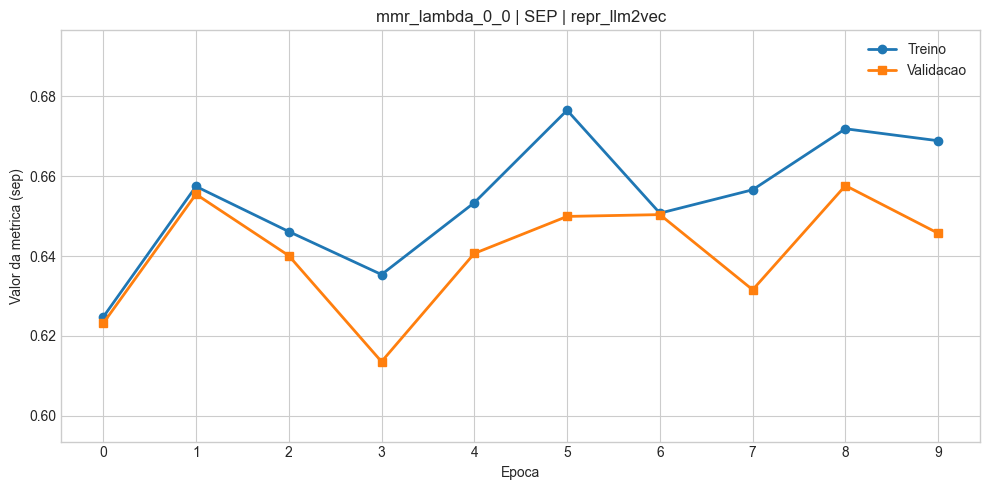

## Prompts por epoca no ncf

### Epoca 0
- Status do prompt: baseline
- Train: 0.6247 (sem anterior)
- Validacao: 0.6232 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 691 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6574 (+0.0327)
- Validacao: 0.6555 (+0.0323)
- Refs MMR: epoca 0 (0.6247)
- Tamanho do prompt: 945 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Explanation Path Selection Criteria**

Prioritize recommendations based on the following sequence:

1. Optimize the attribute choice to yield explanations with higher specificity and differentiation power relative to other options.
2. Prefer attributes offering distinctiveness over ambiguous choices whenever feasible alternatives exist.
3. In cases where multiple candidates possess equivalent levels of specificity and distinctness, favor the path whose bridging attribute provides clearer thematic alignment between interacted and recommended entities.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6461 (-0.0113)
- Validacao: 0.6401 (-0.0154)
- Refs MMR: epoca 1 (0.6574), epoca 0 (0.6247)
- Tamanho do prompt: 1058 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Optimal Recommendation Strategy**
Prioritize explanations based on their unique combination of detail-rich attributes, specific relationships, and clear thematic connections to ensure impactful interactions within our dynamic ecosystem.


1) Emphasize highly detailed attributes leading to sharper comprehension across various aspects and perspectives.
2) De-emphasize vague descriptors to minimize noise and focus on distinctive characteristics highlighting inherent relevance.
3) When parity exists among these metrics, leverage the attribute exhibiting closer conceptual ties between linked objects to maximize understanding and foster a stronger sense of belonging.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6354 (-0.0108)
- Validacao: 0.6136 (-0.0265)
- Refs MMR: epoca 1 (0.6574), epoca 2 (0.6461), epoca 0 (0.6247)
- Tamanho do prompt: 913 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
To achieve optimal recommendation insights prioritize as follows:
  
1 Choose explanations centered around informative and discriminating attributes which distinguish the interacted from the recommended item effectively.
2 Avoid excessively generic attributes if better-descriptive options are present maintaining clarity through nuanced distinctions.
3 When parity is reached in both informativity and descriptivity select the explanation path where the intermediate attribute creates a concise connection between both items.
```

...

Plotando rodada do ncf: out/prompt_optimization/Llama3.1-I/ncf/sep/repr_llm2vec/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do ncf
- Melhor treino: epoca 8 com valor 0.6591
- Melhor validacao: epoca 6 com valor 0.6633
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do ncf
- Metrica de teste (SEP): 0.6362
- Delta vs without_optimization: +0.0395
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 233.16s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/ncf/sep/repr_llm2vec/early_false/mmr_lambda_0_5/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do ncf
- `prompt_chars`: quantidade de caracteres do prompt completo mostrado em cada epoca, incluindo a parte fixa e o guidance otimizado.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.624722,NaN,0.623168,NaN,nao,nao,691,sem refs MMR
1,1,0.657425,0.032703,0.655472,0.032304,sim,sim,945,epoca 0 (0.6247)
2,2,0.646133,-0.011292,0.640104,-0.015368,sim,sim,1058,"epoca 1 (0.6574), epoca 0 (0.6247)"
3,3,0.635373,-0.010761,0.613581,-0.026523,sim,sim,913,"epoca 1 (0.6574), epoca 2 (0.6461), epoca 0 (0..."
4,4,0.637111,0.001738,0.629902,0.016321,sim,sim,892,"epoca 1 (0.6574), epoca 3 (0.6354), epoca 0 (0..."
5,5,0.654462,0.017351,0.639087,0.009185,sim,sim,926,"epoca 1 (0.6574), epoca 4 (0.6371), epoca 3 (0..."
6,6,0.648545,-0.005916,0.663336,0.024249,sim,sim,1134,"epoca 1 (0.6574), epoca 4 (0.6371), epoca 3 (0..."
7,7,0.655959,0.007414,0.643801,-0.019535,sim,sim,856,"epoca 1 (0.6574), epoca 6 (0.6485), epoca 3 (0..."
8,8,0.659136,0.003176,0.659856,0.016055,sim,sim,1377,"epoca 1 (0.6574), epoca 4 (0.6371), epoca 0 (0..."
9,9,0.651101,-0.008035,0.652251,-0.007604,sim,sim,1074,"epoca 8 (0.6591), epoca 5 (0.6545), epoca 0 (0..."


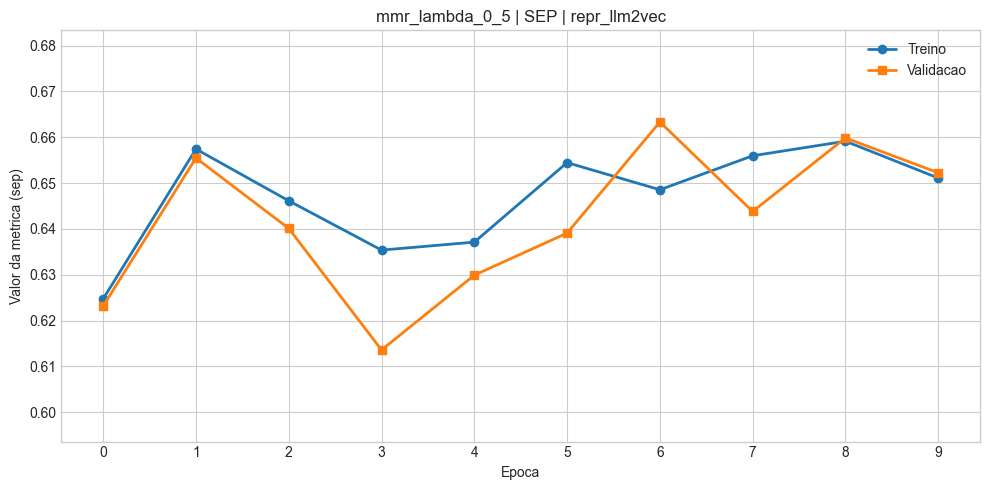

## Prompts por epoca no ncf

### Epoca 0
- Status do prompt: baseline
- Train: 0.6247 (sem anterior)
- Validacao: 0.6232 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 691 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6574 (+0.0327)
- Validacao: 0.6555 (+0.0323)
- Refs MMR: epoca 0 (0.6247)
- Tamanho do prompt: 945 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Explanation Path Selection Criteria**

Prioritize recommendations based on the following sequence:

1. Optimize the attribute choice to yield explanations with higher specificity and differentiation power relative to other options.
2. Prefer attributes offering distinctiveness over ambiguous choices whenever feasible alternatives exist.
3. In cases where multiple candidates possess equivalent levels of specificity and distinctness, favor the path whose bridging attribute provides clearer thematic alignment between interacted and recommended entities.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6461 (-0.0113)
- Validacao: 0.6401 (-0.0154)
- Refs MMR: epoca 1 (0.6574), epoca 0 (0.6247)
- Tamanho do prompt: 1058 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Optimal Recommendation Strategy**
Prioritize explanations based on their unique combination of detail-rich attributes, specific relationships, and clear thematic connections to ensure impactful interactions within our dynamic ecosystem.


1) Emphasize highly detailed attributes leading to sharper comprehension across various aspects and perspectives.
2) De-emphasize vague descriptors to minimize noise and focus on distinctive characteristics highlighting inherent relevance.
3) When parity exists among these metrics, leverage the attribute exhibiting closer conceptual ties between linked objects to maximize understanding and foster a stronger sense of belonging.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6354 (-0.0108)
- Validacao: 0.6136 (-0.0265)
- Refs MMR: epoca 1 (0.6574), epoca 2 (0.6461), epoca 0 (0.6247)
- Tamanho do prompt: 913 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
To achieve optimal recommendation insights prioritize as follows:
  
1 Choose explanations centered around informative and discriminating attributes which distinguish the interacted from the recommended item effectively.
2 Avoid excessively generic attributes if better-descriptive options are present maintaining clarity through nuanced distinctions.
3 When parity is reached in both informativity and descriptivity select the explanation path where the intermediate attribute creates a concise connection between both items.
```

...

Plotando rodada do ncf: out/prompt_optimization/Llama3.1-I/ncf/sep/repr_llm2vec/early_false/mmr_lambda_1_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do ncf
- Melhor treino: epoca 6 com valor 0.6589
- Melhor validacao: epoca 9 com valor 0.6616
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do ncf
- Metrica de teste (SEP): 0.6213
- Delta vs without_optimization: +0.0246
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 228.57s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/ncf/sep/repr_llm2vec/early_false/mmr_lambda_1_0/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do ncf
- `prompt_chars`: quantidade de caracteres do prompt completo mostrado em cada epoca, incluindo a parte fixa e o guidance otimizado.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.624722,NaN,0.623168,NaN,nao,nao,691,sem refs MMR
1,1,0.657425,0.032703,0.655472,0.032304,sim,sim,945,epoca 0 (0.6247)
2,2,0.646133,-0.011292,0.640104,-0.015368,sim,sim,1058,"epoca 1 (0.6574), epoca 0 (0.6247)"
3,3,0.635373,-0.010761,0.613581,-0.026523,sim,sim,913,"epoca 1 (0.6574), epoca 2 (0.6461), epoca 0 (0..."
4,4,0.637111,0.001738,0.629902,0.016321,sim,sim,892,"epoca 1 (0.6574), epoca 3 (0.6354), epoca 0 (0..."
5,5,0.645488,0.008378,0.645722,0.015820,sim,sim,1140,"epoca 1 (0.6574), epoca 3 (0.6354), epoca 0 (0..."
6,6,0.658915,0.013427,0.642422,-0.003300,sim,sim,1044,"epoca 1 (0.6574), epoca 5 (0.6455), epoca 3 (0..."
7,7,0.648879,-0.010036,0.659968,0.017546,sim,sim,961,"epoca 6 (0.6589), epoca 5 (0.6455), epoca 4 (0..."
8,8,0.653046,0.004167,0.637505,-0.022463,sim,sim,930,"epoca 6 (0.6589), epoca 7 (0.6489), epoca 4 (0..."
9,9,0.655828,0.002782,0.661571,0.024066,sim,sim,786,"epoca 6 (0.6589), epoca 7 (0.6489), epoca 4 (0..."


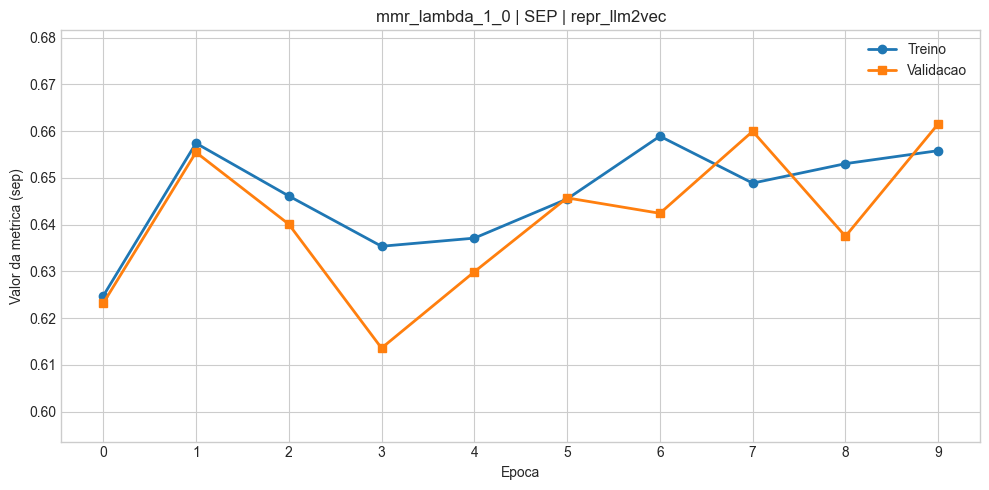

## Prompts por epoca no ncf

### Epoca 0
- Status do prompt: baseline
- Train: 0.6247 (sem anterior)
- Validacao: 0.6232 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 691 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6574 (+0.0327)
- Validacao: 0.6555 (+0.0323)
- Refs MMR: epoca 0 (0.6247)
- Tamanho do prompt: 945 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Explanation Path Selection Criteria**

Prioritize recommendations based on the following sequence:

1. Optimize the attribute choice to yield explanations with higher specificity and differentiation power relative to other options.
2. Prefer attributes offering distinctiveness over ambiguous choices whenever feasible alternatives exist.
3. In cases where multiple candidates possess equivalent levels of specificity and distinctness, favor the path whose bridging attribute provides clearer thematic alignment between interacted and recommended entities.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6461 (-0.0113)
- Validacao: 0.6401 (-0.0154)
- Refs MMR: epoca 1 (0.6574), epoca 0 (0.6247)
- Tamanho do prompt: 1058 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Optimal Recommendation Strategy**
Prioritize explanations based on their unique combination of detail-rich attributes, specific relationships, and clear thematic connections to ensure impactful interactions within our dynamic ecosystem.


1) Emphasize highly detailed attributes leading to sharper comprehension across various aspects and perspectives.
2) De-emphasize vague descriptors to minimize noise and focus on distinctive characteristics highlighting inherent relevance.
3) When parity exists among these metrics, leverage the attribute exhibiting closer conceptual ties between linked objects to maximize understanding and foster a stronger sense of belonging.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6354 (-0.0108)
- Validacao: 0.6136 (-0.0265)
- Refs MMR: epoca 1 (0.6574), epoca 2 (0.6461), epoca 0 (0.6247)
- Tamanho do prompt: 913 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
To achieve optimal recommendation insights prioritize as follows:
  
1 Choose explanations centered around informative and discriminating attributes which distinguish the interacted from the recommended item effectively.
2 Avoid excessively generic attributes if better-descriptive options are present maintaining clarity through nuanced distinctions.
3 When parity is reached in both informativity and descriptivity select the explanation path where the intermediate attribute creates a concise connection between both items.
```

...

Plotando rodada do ncf: out/prompt_optimization/Llama3.1-I/ncf/sep/repr_sbert/early_false/mmr_lambda_0_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do ncf
- Melhor treino: epoca 8 com valor 0.6660
- Melhor validacao: epoca 7 com valor 0.6666
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do ncf
- Metrica de teste (SEP): 0.6514
- Delta vs without_optimization: +0.0547
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 227.71s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/ncf/sep/repr_sbert/early_false/mmr_lambda_0_0/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do ncf
- `prompt_chars`: quantidade de caracteres do prompt completo mostrado em cada epoca, incluindo a parte fixa e o guidance otimizado.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.624722,NaN,0.623168,NaN,nao,nao,691,sem refs MMR
1,1,0.657425,0.032703,0.655472,0.032304,sim,sim,945,epoca 0 (0.6247)
2,2,0.646133,-0.011292,0.640104,-0.015368,sim,sim,1058,"epoca 1 (0.6574), epoca 0 (0.6247)"
3,3,0.635373,-0.010761,0.613581,-0.026523,sim,sim,913,"epoca 1 (0.6574), epoca 2 (0.6461), epoca 0 (0..."
4,4,0.639948,0.004575,0.642681,0.029100,sim,sim,1053,"epoca 1 (0.6574), epoca 2 (0.6461), epoca 3 (0..."
5,5,0.642375,0.002427,0.652761,0.010080,sim,sim,1225,"epoca 1 (0.6574), epoca 2 (0.6461), epoca 4 (0..."
6,6,0.656065,0.013690,0.646336,-0.006425,sim,sim,1089,"epoca 1 (0.6574), epoca 2 (0.6461), epoca 5 (0..."
7,7,0.651525,-0.004540,0.666612,0.020276,sim,sim,1760,"epoca 1 (0.6574), epoca 6 (0.6561), epoca 2 (0..."
8,8,0.666005,0.014479,0.665666,-0.000946,sim,sim,1070,"epoca 1 (0.6574), epoca 6 (0.6561), epoca 7 (0..."
9,9,0.662060,-0.003945,0.649978,-0.015689,sim,sim,1069,"epoca 8 (0.6660), epoca 6 (0.6561), epoca 0 (0..."


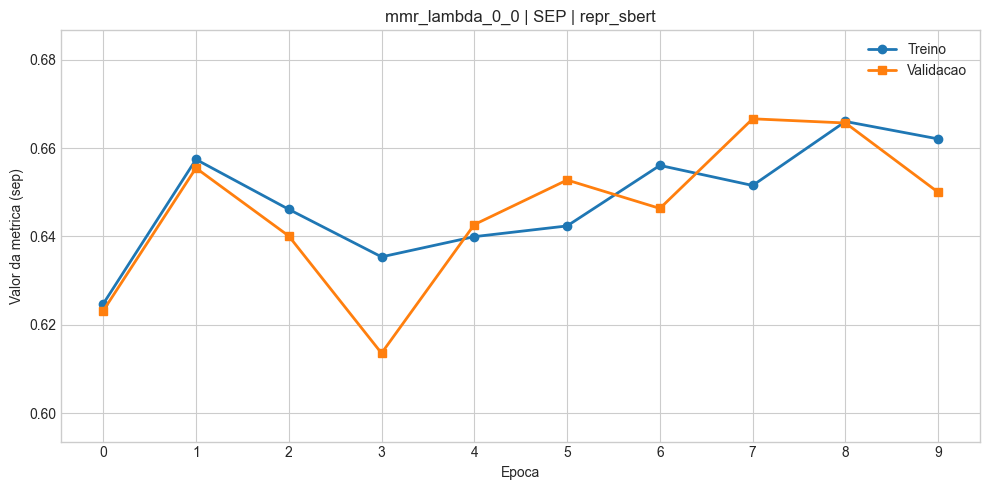

## Prompts por epoca no ncf

### Epoca 0
- Status do prompt: baseline
- Train: 0.6247 (sem anterior)
- Validacao: 0.6232 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 691 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6574 (+0.0327)
- Validacao: 0.6555 (+0.0323)
- Refs MMR: epoca 0 (0.6247)
- Tamanho do prompt: 945 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Explanation Path Selection Criteria**

Prioritize recommendations based on the following sequence:

1. Optimize the attribute choice to yield explanations with higher specificity and differentiation power relative to other options.
2. Prefer attributes offering distinctiveness over ambiguous choices whenever feasible alternatives exist.
3. In cases where multiple candidates possess equivalent levels of specificity and distinctness, favor the path whose bridging attribute provides clearer thematic alignment between interacted and recommended entities.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6461 (-0.0113)
- Validacao: 0.6401 (-0.0154)
- Refs MMR: epoca 1 (0.6574), epoca 0 (0.6247)
- Tamanho do prompt: 1058 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Optimal Recommendation Strategy**
Prioritize explanations based on their unique combination of detail-rich attributes, specific relationships, and clear thematic connections to ensure impactful interactions within our dynamic ecosystem.


1) Emphasize highly detailed attributes leading to sharper comprehension across various aspects and perspectives.
2) De-emphasize vague descriptors to minimize noise and focus on distinctive characteristics highlighting inherent relevance.
3) When parity exists among these metrics, leverage the attribute exhibiting closer conceptual ties between linked objects to maximize understanding and foster a stronger sense of belonging.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6354 (-0.0108)
- Validacao: 0.6136 (-0.0265)
- Refs MMR: epoca 1 (0.6574), epoca 2 (0.6461), epoca 0 (0.6247)
- Tamanho do prompt: 913 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
To achieve optimal recommendation insights prioritize as follows:
  
1 Choose explanations centered around informative and discriminating attributes which distinguish the interacted from the recommended item effectively.
2 Avoid excessively generic attributes if better-descriptive options are present maintaining clarity through nuanced distinctions.
3 When parity is reached in both informativity and descriptivity select the explanation path where the intermediate attribute creates a concise connection between both items.
```

...

Plotando rodada do ncf: out/prompt_optimization/Llama3.1-I/ncf/sep/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do ncf
- Melhor treino: epoca 9 com valor 0.6579
- Melhor validacao: epoca 6 com valor 0.6633
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do ncf
- Metrica de teste (SEP): 0.6393
- Delta vs without_optimization: +0.0426
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 225.45s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/ncf/sep/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do ncf
- `prompt_chars`: quantidade de caracteres do prompt completo mostrado em cada epoca, incluindo a parte fixa e o guidance otimizado.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.624722,NaN,0.623168,NaN,nao,nao,691,sem refs MMR
1,1,0.657425,0.032703,0.655472,0.032304,sim,sim,945,epoca 0 (0.6247)
2,2,0.646133,-0.011292,0.640104,-0.015368,sim,sim,1058,"epoca 1 (0.6574), epoca 0 (0.6247)"
3,3,0.635373,-0.010761,0.613581,-0.026523,sim,sim,913,"epoca 1 (0.6574), epoca 2 (0.6461), epoca 0 (0..."
4,4,0.637111,0.001738,0.629902,0.016321,sim,sim,892,"epoca 1 (0.6574), epoca 3 (0.6354), epoca 0 (0..."
5,5,0.654462,0.017351,0.639087,0.009185,sim,sim,926,"epoca 1 (0.6574), epoca 4 (0.6371), epoca 3 (0..."
6,6,0.648545,-0.005916,0.663336,0.024249,sim,sim,1134,"epoca 1 (0.6574), epoca 4 (0.6371), epoca 3 (0..."
7,7,0.655959,0.007414,0.643801,-0.019535,sim,sim,856,"epoca 1 (0.6574), epoca 6 (0.6485), epoca 3 (0..."
8,8,0.650597,-0.005363,0.647450,0.003649,sim,sim,912,"epoca 1 (0.6574), epoca 7 (0.6560), epoca 5 (0..."
9,9,0.657900,0.007304,0.661651,0.014202,sim,sim,929,"epoca 1 (0.6574), epoca 7 (0.6560), epoca 5 (0..."


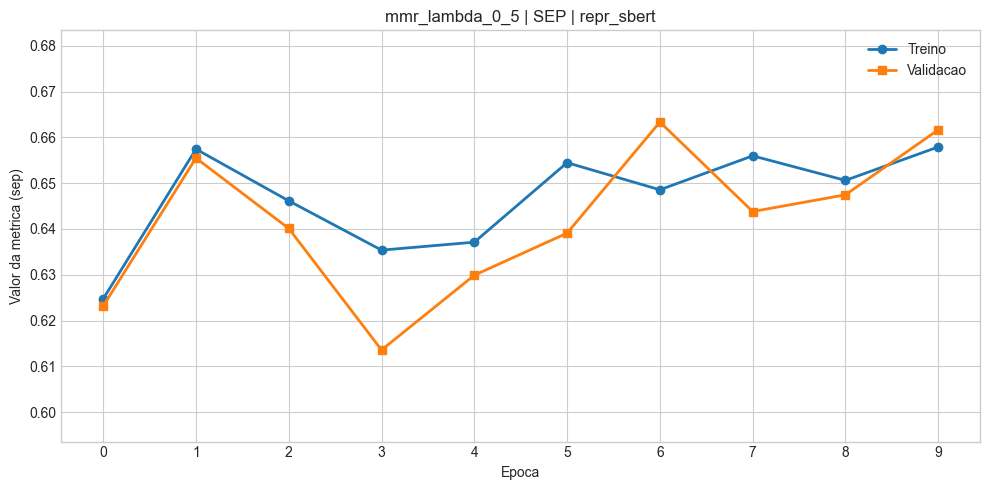

## Prompts por epoca no ncf

### Epoca 0
- Status do prompt: baseline
- Train: 0.6247 (sem anterior)
- Validacao: 0.6232 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 691 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6574 (+0.0327)
- Validacao: 0.6555 (+0.0323)
- Refs MMR: epoca 0 (0.6247)
- Tamanho do prompt: 945 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Explanation Path Selection Criteria**

Prioritize recommendations based on the following sequence:

1. Optimize the attribute choice to yield explanations with higher specificity and differentiation power relative to other options.
2. Prefer attributes offering distinctiveness over ambiguous choices whenever feasible alternatives exist.
3. In cases where multiple candidates possess equivalent levels of specificity and distinctness, favor the path whose bridging attribute provides clearer thematic alignment between interacted and recommended entities.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6461 (-0.0113)
- Validacao: 0.6401 (-0.0154)
- Refs MMR: epoca 1 (0.6574), epoca 0 (0.6247)
- Tamanho do prompt: 1058 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Optimal Recommendation Strategy**
Prioritize explanations based on their unique combination of detail-rich attributes, specific relationships, and clear thematic connections to ensure impactful interactions within our dynamic ecosystem.


1) Emphasize highly detailed attributes leading to sharper comprehension across various aspects and perspectives.
2) De-emphasize vague descriptors to minimize noise and focus on distinctive characteristics highlighting inherent relevance.
3) When parity exists among these metrics, leverage the attribute exhibiting closer conceptual ties between linked objects to maximize understanding and foster a stronger sense of belonging.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6354 (-0.0108)
- Validacao: 0.6136 (-0.0265)
- Refs MMR: epoca 1 (0.6574), epoca 2 (0.6461), epoca 0 (0.6247)
- Tamanho do prompt: 913 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
To achieve optimal recommendation insights prioritize as follows:
  
1 Choose explanations centered around informative and discriminating attributes which distinguish the interacted from the recommended item effectively.
2 Avoid excessively generic attributes if better-descriptive options are present maintaining clarity through nuanced distinctions.
3 When parity is reached in both informativity and descriptivity select the explanation path where the intermediate attribute creates a concise connection between both items.
```

...

Plotando rodada do ncf: out/prompt_optimization/Llama3.1-I/ncf/sep/repr_sbert/early_false/mmr_lambda_1_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep/optimization_process_metadata.json


## Destaques da rodada do ncf
- Melhor treino: epoca 7 com valor 0.6633
- Melhor validacao: epoca 1 com valor 0.6555
- Ultimo prompt avaliado: epoca 9

## Resultado no teste do ncf
- Metrica de teste (SEP): 0.6449
- Delta vs without_optimization: +0.0482
- Prompt source: best_prompt
- Usuarios avaliados: 122
- Tempo para explicar: 225.47s
- Arquivo de origem: `out/test_explainability/with_optimization/Llama3.1-I/ncf/sep/repr_sbert/early_false/mmr_lambda_1_0/mmr_pool_10/responses_metadata.json`

## Como ler a tabela do ncf
- `prompt_chars`: quantidade de caracteres do prompt completo mostrado em cada epoca, incluindo a parte fixa e o guidance otimizado.
- `Refs MMR`: epocas antigas escolhidas como referencia para gerar o prompt atual. O valor aparece como `epoca X (train_score)`.
- `generated_new_prompt`: indica se nessa epoca o prompt foi realmente gerado de novo ou se era o baseline inicial.
- `prompt_changed`: indica se o texto do prompt mudou em relacao a epoca anterior.
- Na epoca 0, `Refs MMR` fica vazio porque ainda nao existem prompts anteriores para servir de referencia.

,epoch,train_metric,train_delta,val_metric,val_delta,generated_new_prompt,prompt_changed,prompt_chars,mmr_refs
0,0,0.624722,NaN,0.623168,NaN,nao,nao,691,sem refs MMR
1,1,0.657425,0.032703,0.655472,0.032304,sim,sim,945,epoca 0 (0.6247)
2,2,0.646133,-0.011292,0.640104,-0.015368,sim,sim,1058,"epoca 1 (0.6574), epoca 0 (0.6247)"
3,3,0.635373,-0.010761,0.613581,-0.026523,sim,sim,913,"epoca 1 (0.6574), epoca 2 (0.6461), epoca 0 (0..."
4,4,0.637111,0.001738,0.629902,0.016321,sim,sim,892,"epoca 1 (0.6574), epoca 3 (0.6354), epoca 0 (0..."
5,5,0.645488,0.008378,0.645722,0.015820,sim,sim,1140,"epoca 1 (0.6574), epoca 3 (0.6354), epoca 0 (0..."
6,6,0.651717,0.006229,0.640370,-0.005352,sim,sim,972,"epoca 1 (0.6574), epoca 3 (0.6354), epoca 0 (0..."
7,7,0.663346,0.011630,0.653713,0.013342,sim,sim,1027,"epoca 1 (0.6574), epoca 6 (0.6517), epoca 0 (0..."
8,8,0.648571,-0.014776,0.653699,-0.000014,sim,sim,1111,"epoca 7 (0.6633), epoca 5 (0.6455), epoca 3 (0..."
9,9,0.636962,-0.011609,0.645097,-0.008602,sim,sim,1091,"epoca 7 (0.6633), epoca 5 (0.6455), epoca 3 (0..."


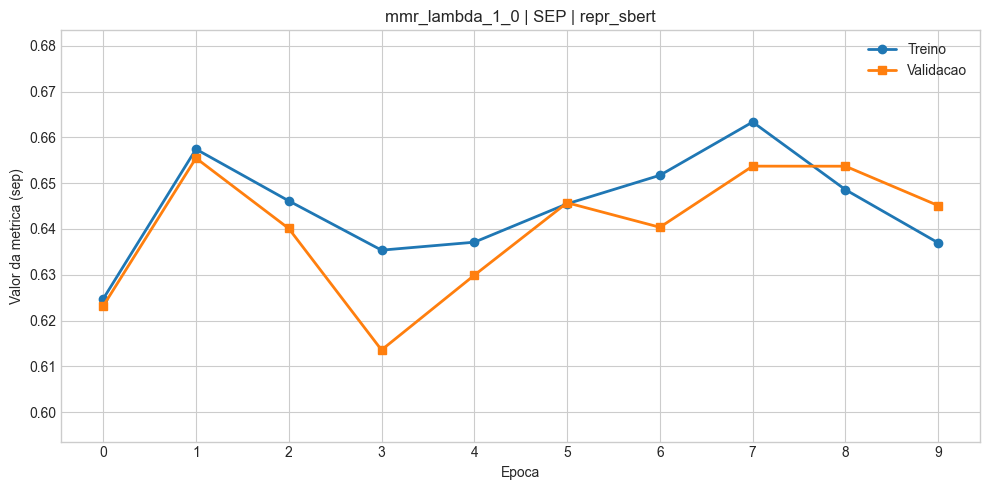

## Prompts por epoca no ncf

### Epoca 0
- Status do prompt: baseline
- Train: 0.6247 (sem anterior)
- Validacao: 0.6232 (sem anterior)
- Refs MMR: sem refs MMR
- Tamanho do prompt: 691 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```

### Epoca 1
- Status do prompt: novo prompt
- Train: 0.6574 (+0.0327)
- Validacao: 0.6555 (+0.0323)
- Refs MMR: epoca 0 (0.6247)
- Tamanho do prompt: 945 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Explanation Path Selection Criteria**

Prioritize recommendations based on the following sequence:

1. Optimize the attribute choice to yield explanations with higher specificity and differentiation power relative to other options.
2. Prefer attributes offering distinctiveness over ambiguous choices whenever feasible alternatives exist.
3. In cases where multiple candidates possess equivalent levels of specificity and distinctness, favor the path whose bridging attribute provides clearer thematic alignment between interacted and recommended entities.
```

### Epoca 2
- Status do prompt: novo prompt
- Train: 0.6461 (-0.0113)
- Validacao: 0.6401 (-0.0154)
- Refs MMR: epoca 1 (0.6574), epoca 0 (0.6247)
- Tamanho do prompt: 1058 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Optimal Recommendation Strategy**
Prioritize explanations based on their unique combination of detail-rich attributes, specific relationships, and clear thematic connections to ensure impactful interactions within our dynamic ecosystem.


1) Emphasize highly detailed attributes leading to sharper comprehension across various aspects and perspectives.
2) De-emphasize vague descriptors to minimize noise and focus on distinctive characteristics highlighting inherent relevance.
3) When parity exists among these metrics, leverage the attribute exhibiting closer conceptual ties between linked objects to maximize understanding and foster a stronger sense of belonging.
```

### Epoca 3
- Status do prompt: novo prompt
- Train: 0.6354 (-0.0108)
- Validacao: 0.6136 (-0.0265)
- Refs MMR: epoca 1 (0.6574), epoca 2 (0.6461), epoca 0 (0.6247)
- Tamanho do prompt: 913 caracteres

Prompt completo:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
To achieve optimal recommendation insights prioritize as follows:
  
1 Choose explanations centered around informative and discriminating attributes which distinguish the interacted from the recommended item effectively.
2 Avoid excessively generic attributes if better-descriptive options are present maintaining clarity through nuanced distinctions.
3 When parity is reached in both informativity and descriptivity select the explanation path where the intermediate attribute creates a concise connection between both items.
```

...

### repr_llm2vec | mmr_lambda_1_0 | mmr_pool_10
- Melhor epoca: 6
- Ganho da melhor epoca vs base no treino: +0.0342 (0.6247 -> 0.6589)
- Ganho da melhor epoca vs base na validacao: +0.0193 (0.6232 -> 0.6424)
- Teste sem otimizacao vs com melhor prompt: 0.5968 -> 0.6213 (+0.0246)
- Prompt base (epoca 0):
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```
- Melhor prompt:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Informed Explanatory Path Guidance**

Follow these strategic priorities to enhance explainability:

1 Ensure maximum explanatory utility by selecting explanations grounded in distinctively discriminative attributes capable of vividly illuminating substantial differences between interrelated elements.
2 Leverage detailed description capabilities offered by non-redundant attribute selections at every step – reject superficial choices wherever preferable nuances can prevail.
3 On encountering equivalences across all prior metrics, favour linking mechanisms wherein attributing middle stages serves seamless continuity within successive transformations.
```

### repr_sbert | mmr_lambda_0_0 | mmr_pool_10
- Melhor epoca: 8
- Ganho da melhor epoca vs base no treino: +0.0413 (0.6247 -> 0.6660)
- Ganho da melhor epoca vs base na validacao: +0.0425 (0.6232 -> 0.6657)
- Teste sem otimizacao vs com melhor prompt: 0.5968 -> 0.6514 (+0.0547)
- Prompt base (epoca 0):
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```
- Melhor prompt:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Structured Attribute Enhancement

Optimize recommendation priorities via carefully chosen attributes as follows:

1. Selectively elevate detail-rich specifications over broadly general terms for enhanced discernibility and relevance.

2. Whenever relevant options present avoid vague or excessively common traits unless context specifically demands lesser-known associations as primary differentiators at least initially.

3. For paths exhibiting comparable specification values favor the attribute linking interacted and recommended items most meaningfully within an interconnected narrative structure promoting greater cohesiveness throughout the resultant justification framework.
```

### repr_sbert | mmr_lambda_0_5 | mmr_pool_10
- Melhor epoca: 9
- Ganho da melhor epoca vs base no treino: +0.0332 (0.6247 -> 0.6579)
- Ganho da melhor epoca vs base na validacao: +0.0385 (0.6232 -> 0.6617)
- Teste sem otimizacao vs com melhor prompt: 0.5968 -> 0.6393 (+0.0426)
- Prompt base (epoca 0):
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```
- Melhor prompt:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Strategic Attribute Alignment Directive**

Instruct the recommendation process according to this strict precedence:
1 Opt for attributes within interactions imbuing maximum informational value through pinpointed association over obscure references.
2 Steer towards elaborate attribute narratives revealing nuanced disparities if substitutable counterparts emerge during deliberations.
3 When matched characteristics prevail select the connection channel exhibiting logical cohesion governing harmonious linkages between the paired entities.
```

### repr_sbert | mmr_lambda_1_0 | mmr_pool_10
- Melhor epoca: 7
- Ganho da melhor epoca vs base no treino: +0.0386 (0.6247 -> 0.6633)
- Ganho da melhor epoca vs base na validacao: +0.0305 (0.6232 -> 0.6537)
- Teste sem otimizacao vs com melhor prompt: 0.5968 -> 0.6449 (+0.0482)
- Prompt base (epoca 0):
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```
- Melhor prompt:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
**Informed Attribute Preference Protocol**
 
 Prioritize recommendation explanations according to the following sequential guidance:

1 Utilize attributes providing quantifiable evidence that explicitly demonstrate how the interactive entity contributes to understanding the proposed suggestion.
2 When alternative attribute possibilities exist, opt instead for those conveying objective comparison metrics rather than general contextual connections alone.
3 Should comparative merits prove balanced upon evaluating these first two considerations, leverage pathways involving intermediate structures forming consistent logical associations.
```

### Comparacao final de teste
- Sem otimizacao: 0.5968 em SEP
- Tempo sem otimizacao: 220.37s
- Prompt sem otimizacao:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Selection criteria (priority order):
1) Prefer attributes that give the most informative, specific, and discriminative explanation.
2) Avoid overly generic attributes when more descriptive ones are available.
3) If tied, prefer the option whose attribute most clearly connects the two items in the path.

```
- Melhor resultado com otimizacao: 0.6514 em SEP
- Melhor configuracao no teste: mmr_lambda_0_0 | repr_sbert
- Tempo da melhor configuracao: 227.71s
- Ganho vs sem otimizacao: +0.0547
- Prompt da melhor configuracao no teste:
```text
You are selecting ONE explanation path for the given recommendation.
Return ONLY the final answer.
Output MUST be exactly ONE token: the OPTION NUMBER.
No extra text.
Rules:
- Choose EXACTLY ONE of the provided numbered paths.
- Do NOT invent items, attributes, or paths.
- Do NOT output words, punctuation, or explanations.
- Output ONLY the integer corresponding to the chosen option.
Structured Attribute Enhancement

Optimize recommendation priorities via carefully chosen attributes as follows:

1. Selectively elevate detail-rich specifications over broadly general terms for enhanced discernibility and relevance.

2. Whenever relevant options present avoid vague or excessively common traits unless context specifically demands lesser-known associations as primary differentiators at least initially.

3. For paths exhibiting comparable specification values favor the attribute linking interacted and recommended items most meaningfully within an interconnected narrative structure promoting greater cohesiveness throughout the resultant justification framework.
```

In [5]:
final_reports = []

if DEFAULT_TEST_RESULT is not None:
    display(Markdown(build_default_test_markdown(DEFAULT_TEST_RESULT)))

if catalog.empty:
    print(f"Nenhum arquivo optimization_process_metadata.json do ncf foi encontrado em {DATA_DIR}.")
else:
    for metadata_path in catalog["optimization_metadata_path"]:
        print(f"Plotando rodada do ncf: {metadata_path.relative_to(PROJECT_ROOT)}")
        plot_history(Path(metadata_path), save_figures=SAVE_FIGURES)

        payload, history, metric_name, lambda_name, pool_name = load_history(Path(metadata_path))
        history_table = build_history_table(history, metric_name, lambda_name, pool_name)
        test_result = find_test_result_for_metadata(Path(metadata_path), payload)
        final_reports.append(
            build_final_report_markdown(
                Path(metadata_path),
                payload,
                history_table,
                test_result,
                DEFAULT_TEST_RESULT,
            )
        )

    display(Markdown("## Relatório Final"))
    for report in final_reports:
        display(Markdown(report))
    display(Markdown(build_best_test_summary_markdown(DEFAULT_TEST_RESULT, with_opt_test_catalog)))

    if SAVE_FIGURES:
        print(f"Figuras do ncf salvas em: {FIGURES_DIR}")
